# DeepLOB

For the current project, the main data-handling choices used in this notebook are:
- the parquet file is sorted by `index`, where the **first row is the earliest observation** and the **last row is the latest observation**,
- labels are mapped from `{-1, 0, 1}` to `{0, 1, 2}`,
- the split is **70% train / 15% validation / 15% test** in chronological order,
- each model input is a rolling window of **100 consecutive LOB snapshots**,
- feature normalization uses **train-only z-score statistics**,
- the model is selected by **validation macro F1**.

The end-to-end pipeline is:
1. check the runtime and GPU environment,
2. load and sort the processed parquet dataset,
3. map labels and split the data chronologically,
4. standardize features using train-only statistics,
5. build rolling LOB sequences,
6. create data loaders and compute effective class weights,
7. define the stable DeepLOB-style model,
8. train with early stopping based on validation macro F1,
9. save and reload the best checkpoint,
10. evaluate on the test set and inspect class-wise behavior.

## Quick Navigation

- [Project Setup And Key Design Choices](#Project-Setup-And-Key-Design-Choices)
- [1. Load And Sort Data](#1.-Load-And-Sort-Data)
- [2. Label Mapping And Chronological Split](#2.-Label-Mapping-And-Chronological-Split)
- [3. Train-Only Standardization](#3.-Train-Only-Standardization)
- [4. Dynamic Sequence Dataset](#4.-Dynamic-Sequence-Dataset)
- [5. Dataloaders And Effective Class Weights](#5.-Dataloaders-And-Effective-Class-Weights)
- [6. Empirically Stable Model](#6.-Empirically-Stable-Model)
- [7. Loss Optimizer And Metrics](#7.-Loss-Optimizer-And-Metrics)
- [8. Training Loop](#8.-Training-Loop)
- [9. Save And Reload](#9.-Save-And-Reload)
- [10. Test Metrics And Per-Class Breakdown](#10.-Test-Metrics-And-Per-Class-Breakdown)

## Project Setup And Key Design Choices

This section summarizes the mathematical objects used throughout the notebook and clarifies what exactly is being modeled.

Let the raw chronological dataset be

$$

\mathcal{D} = \{(\mathrm{index}_t, x_t, y_t)\}_{t=0}^{N-1},
$$

where:
- $x_t \in \mathbb{R}^{20}$ is the 20-dimensional top-5 LOB feature vector,
- $y_t \in \{-1, 0, 1\}$ is the original class label,
- `index_t` preserves the market order of observations.

The learning target is a 3-class classification problem:

$$
y_t \in \{\text{down}, \text{stationary}, \text{up}\}.
$$

The overall notebook logic is:

```text
Parquet Data
    -> chronological sort by index
    -> label mapping and 70/15/15 split
    -> train-only z-score normalization
    -> rolling windows of length 100
    -> DeepLOB-style neural network
    -> validation-based model selection
    -> final test evaluation
```

The key project settings used here are:

| Item | Choice Used In This Notebook |
| --- | --- |
| Time order | Sort by `index` |
| Input feature count | 20 raw LOB features |
| Sequence length | 100 |
| Split strategy | Chronological 70/15/15 |
| Normalization | Train-only z-score |
| Loss | Class-weighted cross-entropy |
| Selection metric | Validation macro F1 |
| Final output | 3 logits for down / stationary / up |

In [1]:
import copy
import random

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset

In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True

print(torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA device count:", torch.cuda.device_count())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

2.7.0+cu128
CUDA available: True
CUDA device count: 1
GPU: NVIDIA GeForce RTX 5090
Using device: cuda


## 1. Load And Sort Data

This section loads the parquet dataset, keeps the `index`, the 20 LOB features, and the label column, and then explicitly sorts all rows by `index`.

The chronological assumption is:

$$
\mathrm{index}_0 < \mathrm{index}_1 < \cdots < \mathrm{index}_{N-1},
$$

so the first row is the earliest observation and the last row is the latest observation.

The data flow in this section is:

```text
test_Xy.parquet
    -> select [index + 20 features + label]
    -> sort by index
    -> reset row numbering
    -> inspect shape / columns / labels
```

This is the first sanity-check stage of the notebook, and it confirms that the downstream split and rolling-window construction will follow the correct temporal order.

### Optional: k=10, k=50 dataset

In [3]:
FILE_PATH = "test_10.parquet"
df = pd.read_parquet(FILE_PATH)
df = df.reset_index()
SEQ_LEN = 100

feature_cols = [
    "BidPrice5", "BidVolume5",
    "BidPrice4", "BidVolume4",
    "BidPrice3", "BidVolume3",
    "BidPrice2", "BidVolume2",
    "BidPrice1", "BidVolume1",
    "AskPrice5", "AskVolume5",
    "AskPrice4", "AskVolume4",
    "AskPrice3", "AskVolume3",
    "AskPrice2", "AskVolume2",
    "AskPrice1", "AskVolume1",
]
label_col = "label"
load_cols = ["index"] + feature_cols + [label_col]
df = df[load_cols]
df = df.sort_values("index").reset_index(drop=True)

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print()
print("Index head/tail:", df["index"].iloc[0], df["index"].iloc[-1])
print()
print("Raw label distribution:")
print(df[label_col].value_counts(dropna=False).sort_index())
print()
print("Raw label share:")
print(df[label_col].value_counts(dropna=False, normalize=True).sort_index())

Shape: (8774466, 22)
Columns: ['index', 'BidPrice5', 'BidVolume5', 'BidPrice4', 'BidVolume4', 'BidPrice3', 'BidVolume3', 'BidPrice2', 'BidVolume2', 'BidPrice1', 'BidVolume1', 'AskPrice5', 'AskVolume5', 'AskPrice4', 'AskVolume4', 'AskPrice3', 'AskVolume3', 'AskPrice2', 'AskVolume2', 'AskPrice1', 'AskVolume1', 'label']

Index head/tail: 0 8774465

Raw label distribution:
label
-1.0    1078043
 0.0    6614408
 1.0    1082015
Name: count, dtype: int64

Raw label share:
label
-1.0    0.122861
 0.0    0.753825
 1.0    0.123314
Name: proportion, dtype: float64


In [12]:
FILE_PATH = "test_Xy.parquet"
SEQ_LEN = 100

feature_cols = [
    "BidPrice5", "BidVolume5",
    "BidPrice4", "BidVolume4",
    "BidPrice3", "BidVolume3",
    "BidPrice2", "BidVolume2",
    "BidPrice1", "BidVolume1",
    "AskPrice5", "AskVolume5",
    "AskPrice4", "AskVolume4",
    "AskPrice3", "AskVolume3",
    "AskPrice2", "AskVolume2",
    "AskPrice1", "AskVolume1",
]
label_col = "label"

load_cols = ["index"] + feature_cols + [label_col]
df = pd.read_parquet(FILE_PATH, columns=load_cols)
df = df.sort_values("index").reset_index(drop=True)

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print()
print("Index head/tail:", df["index"].iloc[0], df["index"].iloc[-1])
print()
print("Raw label distribution:")
print(df[label_col].value_counts(dropna=False).sort_index())
print()
print("Raw label share:")
print(df[label_col].value_counts(dropna=False, normalize=True).sort_index())

Shape: (8770846, 22)
Columns: ['index', 'BidPrice5', 'BidVolume5', 'BidPrice4', 'BidVolume4', 'BidPrice3', 'BidVolume3', 'BidPrice2', 'BidVolume2', 'BidPrice1', 'BidVolume1', 'AskPrice5', 'AskVolume5', 'AskPrice4', 'AskVolume4', 'AskPrice3', 'AskVolume3', 'AskPrice2', 'AskVolume2', 'AskPrice1', 'AskVolume1', 'label']

Index head/tail: 0 8770845

Raw label distribution:
label
-1.0    1116268
 0.0    6538661
 1.0    1115917
Name: count, dtype: int64

Raw label share:
label
-1.0    0.127270
 0.0    0.745499
 1.0    0.127230
Name: proportion, dtype: float64


## 2. Label Mapping And Chronological Split

This section converts the raw labels into class ids and splits the full dataset into train, validation, and test segments by time.

The label mapping is:

$$
-1 \mapsto 0, \qquad 0 \mapsto 1, \qquad 1 \mapsto 2.
$$

If the full dataset length is $N$, then the split boundaries are:

$$
N_{\text{train}} = \lfloor 0.70N \rfloor,
\qquad
N_{\text{valid}} = \lfloor 0.85N \rfloor.
$$

Therefore:

$$
\mathcal{D}_{\text{train}} = [0, N_{\text{train}}),
$$

$$
\mathcal{D}_{\text{valid}} = [N_{\text{train}}, N_{\text{valid}}),
$$

$$
\mathcal{D}_{\text{test}} = [N_{\text{valid}}, N).
$$

The chronological split structure is:

```text
earliest ------------------------------------------------------------> latest
|------------------- train 70% -------------------|---- valid 15% ----|---- test 15% ----|
```

This section also prints class proportions in each split so we can verify that the class balance remains broadly consistent across time.

In [4]:
label_map = {-1.0: 0, 0.0: 1, 1.0: 2}
df["label_cls"] = df[label_col].map(label_map).astype(np.int64)

n = len(df)
train_end = int(n * 0.70)
valid_end = int(n * 0.85)

train_df = df.iloc[:train_end].copy()
valid_df = df.iloc[train_end:valid_end].copy()
test_df = df.iloc[valid_end:].copy()

def show_label_dist(name, data, col="label_cls"):
    print(name)
    print(data[col].value_counts(normalize=True).sort_index())
    print()

print("Split sizes:")
print("train:", train_df.shape)
print("valid:", valid_df.shape)
print("test :", test_df.shape)
print()

show_label_dist("train label share", train_df)
show_label_dist("valid label share", valid_df)
show_label_dist("test label share", test_df)

X_train_raw = train_df[feature_cols].to_numpy(dtype=np.float32)
y_train = train_df["label_cls"].to_numpy(dtype=np.int64)

X_valid_raw = valid_df[feature_cols].to_numpy(dtype=np.float32)
y_valid = valid_df["label_cls"].to_numpy(dtype=np.int64)

X_test_raw = test_df[feature_cols].to_numpy(dtype=np.float32)
y_test = test_df["label_cls"].to_numpy(dtype=np.int64)

print("Raw array shapes:")
print("X_train_raw:", X_train_raw.shape, "y_train:", y_train.shape)
print("X_valid_raw:", X_valid_raw.shape, "y_valid:", y_valid.shape)
print("X_test_raw :", X_test_raw.shape, "y_test :", y_test.shape)

Split sizes:
train: (6142126, 23)
valid: (1316170, 23)
test : (1316170, 23)

train label share
label_cls
0    0.123593
1    0.752783
2    0.123624
Name: proportion, dtype: float64

valid label share
label_cls
0    0.119346
1    0.758669
2    0.121984
Name: proportion, dtype: float64

test label share
label_cls
0    0.122961
1    0.753841
2    0.123198
Name: proportion, dtype: float64

Raw array shapes:
X_train_raw: (6142126, 20) y_train: (6142126,)
X_valid_raw: (1316170, 20) y_valid: (1316170,)
X_test_raw : (1316170, 20) y_test : (1316170,)


## 3. Train-Only Standardization

This section normalizes each feature using statistics computed **only from the training set**.

For feature dimension $j$, the training mean and standard deviation are:

$$
\mu_j = \frac{1}{N_{\text{train}}} \sum_{t \in \mathcal{D}_{\text{train}}} x_{t,j},
$$

$$
\sigma_j = \sqrt{\frac{1}{N_{\text{train}}} \sum_{t \in \mathcal{D}_{\text{train}}} (x_{t,j} - \mu_j)^2}.
$$

Then each split is transformed by:

$$
\tilde{x}_{t,j} = \frac{x_{t,j} - \mu_j}{\sigma_j}.
$$

The normalization flow is:

```text
train features -> compute mean/std -> normalize train
                             -> normalize valid with same stats
                             -> normalize test  with same stats
```

This avoids information leakage from future data while keeping the feature scales numerically stable for the neural network.

In [5]:
train_mean = X_train_raw.mean(axis=0)
train_std = X_train_raw.std(axis=0)
train_std = np.where(train_std < 1e-8, 1.0, train_std)

X_train = (X_train_raw - train_mean) / train_std
X_valid = (X_valid_raw - train_mean) / train_std
X_test = (X_test_raw - train_mean) / train_std

print("Normalized array shapes:")
print("X_train:", X_train.shape)
print("X_valid:", X_valid.shape)
print("X_test :", X_test.shape)
print()
print("Train normalized mean (first 10 cols):")
print(np.round(X_train.mean(axis=0)[:10], 4))
print()
print("Train normalized std (first 10 cols):")
print(np.round(X_train.std(axis=0)[:10], 4))
print()
print("Valid normalized mean (first 10 cols):")
print(np.round(X_valid.mean(axis=0)[:10], 4))
print()
print("Test normalized mean (first 10 cols):")
print(np.round(X_test.mean(axis=0)[:10], 4))

Normalized array shapes:
X_train: (6142126, 20)
X_valid: (1316170, 20)
X_test : (1316170, 20)

Train normalized mean (first 10 cols):
[-0.  0.  0. -0. -0.  0. -0.  0.  0.  0.]

Train normalized std (first 10 cols):
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]

Valid normalized mean (first 10 cols):
[-0.807   0.0434 -0.8071  0.0778 -0.8071  0.1032 -0.8072  0.1165 -0.8072
  0.0976]

Test normalized mean (first 10 cols):
[-0.994   0.1717 -0.9941  0.2722 -0.9942  0.3317 -0.9943  0.3219 -0.9944
  0.345 ]


## 4. Dynamic Sequence Dataset

This section converts the row-wise tabular data into rolling windows so the model can see temporal context.

With sequence length $L = 100$, the $i$-th sequence is:

$$
X_i = [\tilde{x}_i, \tilde{x}_{i+1}, \ldots, \tilde{x}_{i+L-1}] \in \mathbb{R}^{100 \times 20},
$$

and the corresponding target is the label of the **last row in the window**:

$$
Y_i = y_{i+L-1}.
$$

The resulting sequence count is:

$$
N_{\text{seq}} = N_{\text{rows}} - L + 1.
$$

The sequence construction logic is:

```text
row t      row t+1      ...      row t+99
  |           |                    |
  +-----------+-------- ... -------+
                -> one input sample of shape (100, 20)
                -> target = label at row t+99
```

This dynamic dataset design avoids explicitly materializing every rolling window in RAM, which is important for a dataset with millions of rows.

In [6]:
class LOBSequenceDataset(Dataset):
    def __init__(self, X, y, seq_len=100):
        assert len(X) == len(y), "X and y must have the same length."
        assert len(X) >= seq_len, "Sequence length is larger than dataset length."

        self.X = X
        self.y = y
        self.seq_len = seq_len
        self.window_targets = y[seq_len - 1 :]

    def __len__(self):
        return len(self.X) - self.seq_len + 1

    def __getitem__(self, idx):
        x_seq = self.X[idx : idx + self.seq_len]
        y_target = self.y[idx + self.seq_len - 1]
        return torch.tensor(x_seq, dtype=torch.float32), torch.tensor(y_target, dtype=torch.long)


train_dataset = LOBSequenceDataset(X_train, y_train, seq_len=SEQ_LEN)
valid_dataset = LOBSequenceDataset(X_valid, y_valid, seq_len=SEQ_LEN)
test_dataset = LOBSequenceDataset(X_test, y_test, seq_len=SEQ_LEN)

print("Dataset lengths:")
print("train:", len(train_dataset))
print("valid:", len(valid_dataset))
print("test :", len(test_dataset))

x0, y0 = train_dataset[0]
print()
print("One sample shape:", x0.shape)
print("One target:", y0.item())

Dataset lengths:
train: 6142027
valid: 1316071
test : 1316071

One sample shape: torch.Size([100, 20])
One target: 2


## 5. Dataloaders And Effective Class Weights

This section builds PyTorch dataloaders and computes class weights from the **effective sequence targets** rather than the raw row labels.

If the effective number of training windows in class $c$ is $n_c$, and the number of classes is $C = 3$, then the class weight used here is:

$$
w_c = \frac{M}{C \cdot n_c},
$$

where $M$ is the total number of effective training windows.

The loader setup is:

```text
train_dataset -> train_loader (shuffle = True)
valid_dataset -> valid_loader (shuffle = False)
test_dataset  -> test_loader  (shuffle = False)
```

The purpose of this section is twofold:
- create mini-batches of shape `(batch_size, 100, 20)`,
- compensate for the strong dominance of the `stationary` class during optimization.

In [7]:
BATCH_SIZE = 1024

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

effective_train_labels = train_dataset.window_targets
class_counts = np.bincount(effective_train_labels, minlength=3)
class_weights = len(effective_train_labels) / (len(class_counts) * class_counts)
class_weights = torch.tensor(class_weights, dtype=torch.float32, device=device)

print("Effective train class counts:", class_counts)
print("Class weights:", class_weights)

xb, yb = next(iter(train_loader))
print()
print("One batch shape:", xb.shape)
print("One batch target shape:", yb.shape)

Effective train class counts: [ 759077 4623680  759270]
Class weights: tensor([2.6971, 0.4428, 2.6965], device='cuda:0')

One batch shape: torch.Size([1024, 100, 20])
One batch target shape: torch.Size([1024])


## 6. Empirically Stable Model

This section defines the neural network that currently gives the most stable performance on this dataset.

The model flow is:

```text
Input sequence (B, 100, 20)
    -> unsqueeze channel dimension
    -> convolution block
    -> inception-style multi-branch temporal block
    -> concatenate branch outputs
    -> mean over feature width
    -> LSTM over time
    -> dropout
    -> linear classifier
    -> logits for 3 classes
```

A simplified shape diagram is:

| Stage | Operation | Output Shape |
| --- | --- | --- |
| Input | LOB sequence | `(B, 100, 20)` |
| Reshape | add channel | `(B, 1, 100, 20)` |
| Conv block | local feature extraction | `(B, 32, 100, W')` |
| Inception block | multi-scale temporal features | `(B, 128, 100, W')` |
| Width pooling | mean over width | `(B, 128, 100)` |
| Transpose | time-major for LSTM | `(B, 100, 128)` |
| LSTM | sequence modeling | `(B, 100, 64)` |
| Head | last hidden -> FC | `(B, 3)` |

In formula form, the network can be summarized as:

$$
z = f_{\text{FC}}\big(f_{\text{LSTM}}(f_{\text{Inception}}(f_{\text{Conv}}(X)))\big),
$$

where $z \in \mathbb{R}^3$ is the output logit vector for `down`, `stationary`, and `up`.

In [8]:
class DeepLOB5Stable(nn.Module):
    def __init__(self, num_classes=3, hidden_size=64):
        super().__init__()

        self.conv_block = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=(1, 2), padding=(0, 1)),
            nn.LeakyReLU(0.01, inplace=True),
            nn.Conv2d(16, 16, kernel_size=(3, 1), padding=(1, 0)),
            nn.LeakyReLU(0.01, inplace=True),
            nn.Conv2d(16, 32, kernel_size=(1, 2), padding=(0, 0)),
            nn.LeakyReLU(0.01, inplace=True),
        )

        self.branch1 = nn.Sequential(
            nn.Conv2d(32, 32, kernel_size=(1, 1), padding=0),
            nn.LeakyReLU(0.01, inplace=True),
        )

        self.branch3 = nn.Sequential(
            nn.Conv2d(32, 32, kernel_size=(1, 1), padding=0),
            nn.LeakyReLU(0.01, inplace=True),
            nn.Conv2d(32, 32, kernel_size=(3, 1), padding=(1, 0)),
            nn.LeakyReLU(0.01, inplace=True),
        )

        self.branch5 = nn.Sequential(
            nn.Conv2d(32, 32, kernel_size=(1, 1), padding=0),
            nn.LeakyReLU(0.01, inplace=True),
            nn.Conv2d(32, 32, kernel_size=(5, 1), padding=(2, 0)),
            nn.LeakyReLU(0.01, inplace=True),
        )

        self.branch_pool = nn.Sequential(
            nn.MaxPool2d(kernel_size=(3, 1), stride=(1, 1), padding=(1, 0)),
            nn.Conv2d(32, 32, kernel_size=(1, 1), padding=0),
            nn.LeakyReLU(0.01, inplace=True),
        )

        self.lstm = nn.LSTM(
            input_size=128,
            hidden_size=hidden_size,
            num_layers=1,
            batch_first=True,
        )

        self.dropout = nn.Dropout(0.2)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        x = x.unsqueeze(1)
        x = self.conv_block(x)

        b1 = self.branch1(x)
        b3 = self.branch3(x)
        b5 = self.branch5(x)
        bp = self.branch_pool(x)

        x = torch.cat([b1, b3, b5, bp], dim=1)
        x = x.mean(dim=3)
        x = x.transpose(1, 2)
        x, _ = self.lstm(x)
        x = x[:, -1, :]
        x = self.dropout(x)
        return self.fc(x)


model = DeepLOB5Stable(num_classes=3, hidden_size=64).to(device)

xb, yb = next(iter(train_loader))
xb = xb.to(device)
yb = yb.to(device)

with torch.no_grad():
    logits = model(xb)

print(model)
print()
print("Input batch shape :", xb.shape)
print("Logits shape      :", logits.shape)
print("Target shape      :", yb.shape)

DeepLOB5Stable(
  (conv_block): Sequential(
    (0): Conv2d(1, 16, kernel_size=(1, 2), stride=(1, 1), padding=(0, 1))
    (1): LeakyReLU(negative_slope=0.01, inplace=True)
    (2): Conv2d(16, 16, kernel_size=(3, 1), stride=(1, 1), padding=(1, 0))
    (3): LeakyReLU(negative_slope=0.01, inplace=True)
    (4): Conv2d(16, 32, kernel_size=(1, 2), stride=(1, 1))
    (5): LeakyReLU(negative_slope=0.01, inplace=True)
  )
  (branch1): Sequential(
    (0): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1))
    (1): LeakyReLU(negative_slope=0.01, inplace=True)
  )
  (branch3): Sequential(
    (0): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1))
    (1): LeakyReLU(negative_slope=0.01, inplace=True)
    (2): Conv2d(32, 32, kernel_size=(3, 1), stride=(1, 1), padding=(1, 0))
    (3): LeakyReLU(negative_slope=0.01, inplace=True)
  )
  (branch5): Sequential(
    (0): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1))
    (1): LeakyReLU(negative_slope=0.01, inplace=True)
    (2): Conv2d(32, 32, kernel_

## 7. Loss Optimizer And Metrics

This section specifies how the model is optimized and how model quality is measured.

The weighted cross-entropy loss is:

$$
\mathcal{L} = -\frac{1}{M} \sum_{i=1}^{M} w_{y_i} \log p(y_i \mid X_i),
$$

where $w_{y_i}$ is the class weight of the target class for sample $i$.

The main selection metric is **macro F1**, defined as:

$$
\text{MacroF1} = \frac{1}{3} \sum_{c=1}^{3} F1_c.
$$

with

$$
F1_c = \frac{2 \cdot \mathrm{Precision}_c \cdot \mathrm{Recall}_c}{\mathrm{Precision}_c + \mathrm{Recall}_c}.
$$

The optimization structure is:

```text
logits -> weighted cross-entropy loss -> backpropagation -> Adam update
```

We track both accuracy and macro F1, but the checkpoint selection is based on macro F1 because it reflects all three classes more fairly.

In [9]:
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)


def macro_f1_score(y_true, y_pred, num_classes=3):
    f1_list = []
    for c in range(num_classes):
        tp = np.sum((y_true == c) & (y_pred == c))
        fp = np.sum((y_true != c) & (y_pred == c))
        fn = np.sum((y_true == c) & (y_pred != c))

        precision = tp / (tp + fp + 1e-12)
        recall = tp / (tp + fn + 1e-12)
        f1 = 2 * precision * recall / (precision + recall + 1e-12)
        f1_list.append(f1)

    return float(np.mean(f1_list))


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()

    total_loss = 0.0
    total_correct = 0
    total_count = 0
    all_preds = []
    all_targets = []

    for xb, yb in loader:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        logits = model(xb)
        loss = criterion(logits, yb)
        preds = torch.argmax(logits, dim=1)

        batch_size = xb.size(0)
        total_loss += loss.item() * batch_size
        total_correct += (preds == yb).sum().item()
        total_count += batch_size

        all_preds.append(preds.cpu().numpy())
        all_targets.append(yb.cpu().numpy())

    all_preds = np.concatenate(all_preds)
    all_targets = np.concatenate(all_targets)

    return {
        "loss": total_loss / total_count,
        "accuracy": total_correct / total_count,
        "macro_f1": macro_f1_score(all_targets, all_preds, num_classes=3),
    }


initial_val_metrics = evaluate(model, valid_loader, criterion, device)
print("Initial validation metrics:")
print(initial_val_metrics)

Initial validation metrics:
{'loss': 1.103743887937233, 'accuracy': 0.12197898137714455, 'macro_f1': 0.07247847086957952}


## 8. Training Loop

This section performs iterative model training and validation across epochs.

The control flow is:

```text
for each epoch:
    1. train on all training batches
    2. evaluate on validation set
    3. record loss / accuracy / macro F1
    4. if validation macro F1 improves:
           save best state
           reset patience
       else:
           increase patience counter
    5. stop if patience limit is reached
```

If we denote the validation macro F1 at epoch $e$ by $F^{(e)}_{\text{val}}$, then the best checkpoint is updated whenever:

$$
F^{(e)}_{\text{val}} > \max_{k < e} F^{(k)}_{\text{val}}.
$$

This design ensures that the final model corresponds to the strongest observed validation performance rather than simply the last training epoch.

In [10]:
import time

EPOCHS = 100
PATIENCE = 20


def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    total_loss = 0.0
    total_correct = 0
    total_count = 0
    all_preds = []
    all_targets = []

    for xb, yb in loader:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        preds = torch.argmax(logits, dim=1)

        batch_size = xb.size(0)
        total_loss += loss.item() * batch_size
        total_correct += (preds == yb).sum().item()
        total_count += batch_size

        all_preds.append(preds.detach().cpu().numpy())
        all_targets.append(yb.detach().cpu().numpy())

    all_preds = np.concatenate(all_preds)
    all_targets = np.concatenate(all_targets)

    return {
        "loss": total_loss / total_count,
        "accuracy": total_correct / total_count,
        "macro_f1": macro_f1_score(all_targets, all_preds, num_classes=3),
    }


history = []
best_val_f1 = -1.0
best_epoch = -1
best_state_dict = None
patience_counter = 0

for epoch in range(1, EPOCHS + 1):
    start_time = time.time()

    train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_metrics = evaluate(model, valid_loader, criterion, device)
    elapsed = time.time() - start_time

    row = {
        "epoch": epoch,
        "train_loss": train_metrics["loss"],
        "train_acc": train_metrics["accuracy"],
        "train_f1": train_metrics["macro_f1"],
        "val_loss": val_metrics["loss"],
        "val_acc": val_metrics["accuracy"],
        "val_f1": val_metrics["macro_f1"],
        "time_sec": elapsed,
    }
    history.append(row)

    print(
        f"Epoch {epoch:02d} | "
        f"train_loss={row['train_loss']:.4f} train_acc={row['train_acc']:.4f} train_f1={row['train_f1']:.4f} | "
        f"val_loss={row['val_loss']:.4f} val_acc={row['val_acc']:.4f} val_f1={row['val_f1']:.4f} | "
        f"time={row['time_sec']:.1f}s"
    )

    if row["val_f1"] > best_val_f1:
        best_val_f1 = row["val_f1"]
        best_epoch = epoch
        best_state_dict = copy.deepcopy(model.state_dict())
        patience_counter = 0
        print(f"  -> New best model saved at epoch {epoch} (val_f1={best_val_f1:.4f})")
    else:
        patience_counter += 1
        print(f"  -> No improvement. Patience {patience_counter}/{PATIENCE}")

    if patience_counter >= PATIENCE:
        print()
        print("Early stopping triggered.")
        break

if best_state_dict is not None:
    model.load_state_dict(best_state_dict)

print()
print("Best epoch:", best_epoch)
print("Best validation macro F1:", best_val_f1)

Epoch 01 | train_loss=1.0673 train_acc=0.5302 train_f1=0.3772 | val_loss=1.0557 val_acc=0.6208 val_f1=0.3871 | time=373.1s
  -> New best model saved at epoch 1 (val_f1=0.3871)
Epoch 02 | train_loss=1.0582 train_acc=0.5425 train_f1=0.3927 | val_loss=1.0512 val_acc=0.5801 val_f1=0.4040 | time=336.8s
  -> New best model saved at epoch 2 (val_f1=0.4040)
Epoch 03 | train_loss=1.0512 train_acc=0.5379 train_f1=0.3999 | val_loss=1.0418 val_acc=0.6150 val_f1=0.4255 | time=335.4s
  -> New best model saved at epoch 3 (val_f1=0.4255)
Epoch 04 | train_loss=1.0380 train_acc=0.5318 train_f1=0.4092 | val_loss=1.0190 val_acc=0.6310 val_f1=0.4496 | time=335.9s
  -> New best model saved at epoch 4 (val_f1=0.4496)
Epoch 05 | train_loss=1.0128 train_acc=0.5227 train_f1=0.4209 | val_loss=1.0010 val_acc=0.6165 val_f1=0.4586 | time=337.0s
  -> New best model saved at epoch 5 (val_f1=0.4586)
Epoch 06 | train_loss=1.0026 train_acc=0.5218 train_f1=0.4251 | val_loss=0.9939 val_acc=0.6344 val_f1=0.4677 | time=336.

,epoch,train_loss,train_acc,train_f1,val_loss,val_acc,val_f1,time_sec
42,43,0.770414,0.573378,0.512694,0.771282,0.637280,0.549029,337.816528
43,44,0.753230,0.578346,0.520253,0.770906,0.651684,0.557600,336.537845
44,45,0.748279,0.580323,0.522748,0.774295,0.638443,0.549240,337.720934
45,46,0.747915,0.580724,0.523149,0.769236,0.642750,0.552854,336.154678
46,47,0.748981,0.579868,0.522296,0.773472,0.653216,0.558004,337.222633


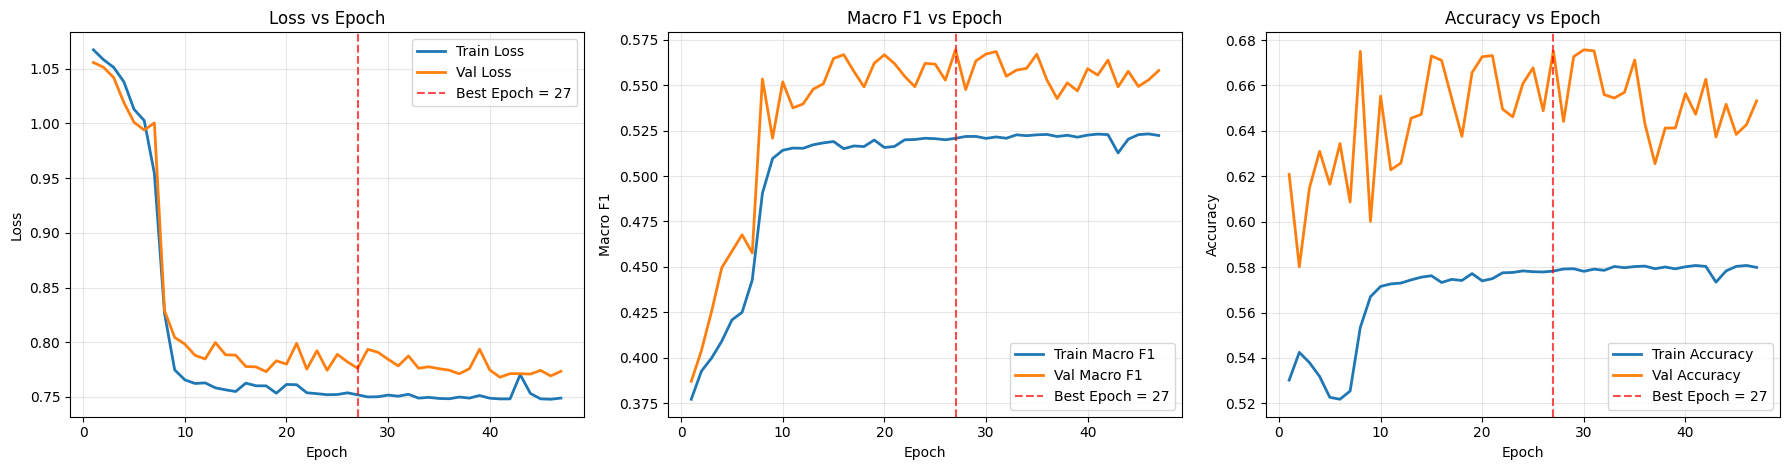

In [11]:
  import pandas as pd
  import matplotlib.pyplot as plt

  history_df = pd.DataFrame(history)

  display(history_df.tail())

  fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))

  # 1. Loss curves
  axes[0].plot(history_df["epoch"], history_df["train_loss"], label="Train Loss", linewidth=2)
  axes[0].plot(history_df["epoch"], history_df["val_loss"], label="Val Loss", linewidth=2)
  axes[0].axvline(best_epoch, color="red", linestyle="--", alpha=0.7, label=f"Best Epoch = {best_epoch}")
  axes[0].set_title("Loss vs Epoch")
  axes[0].set_xlabel("Epoch")
  axes[0].set_ylabel("Loss")
  axes[0].grid(alpha=0.3)
  axes[0].legend()

  # 2. Macro F1 curves
  axes[1].plot(history_df["epoch"], history_df["train_f1"], label="Train Macro F1", linewidth=2)
  axes[1].plot(history_df["epoch"], history_df["val_f1"], label="Val Macro F1", linewidth=2)
  axes[1].axvline(best_epoch, color="red", linestyle="--", alpha=0.7, label=f"Best Epoch = {best_epoch}")
  axes[1].set_title("Macro F1 vs Epoch")
  axes[1].set_xlabel("Epoch")
  axes[1].set_ylabel("Macro F1")
  axes[1].grid(alpha=0.3)
  axes[1].legend()

  # 3. Accuracy curves
  axes[2].plot(history_df["epoch"], history_df["train_acc"], label="Train Accuracy", linewidth=2)
  axes[2].plot(history_df["epoch"], history_df["val_acc"], label="Val Accuracy", linewidth=2)
  axes[2].axvline(best_epoch, color="red", linestyle="--", alpha=0.7, label=f"Best Epoch = {best_epoch}")
  axes[2].set_title("Accuracy vs Epoch")
  axes[2].set_xlabel("Epoch")
  axes[2].set_ylabel("Accuracy")
  axes[2].grid(alpha=0.3)
  axes[2].legend()

  plt.tight_layout()
  plt.show()

## 9. Save And Reload

This section saves the best checkpoint to disk and immediately reloads it as a consistency check.

The checkpoint contains:
- the best `model_state_dict`,
- the feature ordering,
- the sequence length,
- the number of classes,
- the hidden size,
- the batch size,
- the best epoch,
- the best validation macro F1.

The save-reload flow is:

```text
best in-memory model
    -> save checkpoint (.pth)
    -> reload checkpoint
    -> rebuild model object
    -> load saved weights
    -> verify the model is ready for test evaluation
```

This section is a practical reproducibility check and confirms that the training result can be restored later without rerunning the whole notebook.

In [12]:
SAVE_PATH = "deeplob5_stabilized_best_10.pth"
checkpoint = {
    "model_state_dict": model.state_dict(),
    "feature_cols": feature_cols,
    "seq_len": SEQ_LEN,
    "num_classes": 3,
    "hidden_size": 64,
    "batch_size": BATCH_SIZE,
    "best_epoch": best_epoch,
    "best_val_f1": best_val_f1,
    "sorted_by_index": True,
}

torch.save(checkpoint, SAVE_PATH)
print("Best model saved to:", SAVE_PATH)

Best model saved to: deeplob5_stabilized_best_10.pth


In [13]:
SAVE_PATH = "deeplob5_stabilized_best_10.pth"
loaded_ckpt = torch.load(SAVE_PATH, map_location=device)
loaded_model = DeepLOB5Stable(
    num_classes=loaded_ckpt["num_classes"],
    hidden_size=loaded_ckpt["hidden_size"],
).to(device)

loaded_model.load_state_dict(loaded_ckpt["model_state_dict"])
loaded_model.eval()

print("Model loaded successfully.")
print("Loaded best_epoch:", loaded_ckpt["best_epoch"])
print("Loaded best_val_f1:", loaded_ckpt["best_val_f1"])

Model loaded successfully.
Loaded best_epoch: 27
Loaded best_val_f1: 0.569407166602569


## 10. Test Metrics And Per-Class Breakdown

This section evaluates the best saved model on the held-out test set and reports both overall and class-wise behavior.

The confusion matrix is defined as:

$$
C_{ij} = \#\{\text{samples with true class } i \text{ and predicted class } j\}.
$$

For each class $c$, we compute:

$$
\mathrm{Precision}_c = \frac{TP_c}{TP_c + FP_c},
$$

$$
\mathrm{Recall}_c = \frac{TP_c}{TP_c + FN_c},
$$

$$
F1_c = \frac{2 \cdot \mathrm{Precision}_c \cdot \mathrm{Recall}_c}{\mathrm{Precision}_c + \mathrm{Recall}_c}.
$$

The evaluation flow is:

```text
best checkpoint
    -> test_loader
    -> predictions
    -> overall loss / accuracy / macro F1
    -> confusion matrix
    -> per-class precision / recall / F1
```

This final section tells us not only whether the model performs well overall, but also whether it treats `down`, `stationary`, and `up` in a balanced way.

In [ ]:
test_metrics = evaluate(loaded_model, test_loader, criterion, device)
print("Best model test metrics:")
print(test_metrics)


@torch.no_grad()
def collect_predictions(model, loader, device):
    model.eval()

    all_preds = []
    all_targets = []

    for xb, yb in loader:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        logits = model(xb)
        preds = torch.argmax(logits, dim=1)

        all_preds.append(preds.cpu().numpy())
        all_targets.append(yb.cpu().numpy())

    return np.concatenate(all_targets), np.concatenate(all_preds)


y_true_test, y_pred_test = collect_predictions(loaded_model, test_loader, device)

num_classes = 3
class_names = ["down", "stationary", "up"]

cm = np.zeros((num_classes, num_classes), dtype=np.int64)
for t, p in zip(y_true_test, y_pred_test):
    cm[t, p] += 1

cm_df = pd.DataFrame(
    cm,
    index=[f"true_{c}" for c in class_names],
    columns=[f"pred_{c}" for c in class_names],
)

print()
print("Confusion Matrix:")
print(cm_df)

rows = []
for c, name in enumerate(class_names):
    tp = cm[c, c]
    fp = cm[:, c].sum() - tp
    fn = cm[c, :].sum() - tp
    support = cm[c, :].sum()

    precision = tp / (tp + fp + 1e-12)
    recall = tp / (tp + fn + 1e-12)
    f1 = 2 * precision * recall / (precision + recall + 1e-12)

    rows.append(
        {
            "class": name,
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "support": int(support),
        }
    )

per_class_df = pd.DataFrame(rows)

print()
print("Per-class metrics:")
print(per_class_df)
print()
print("Macro F1 from per-class table:", per_class_df["f1"].mean())

Best model test metrics:
{'loss': 0.7700842515193654, 'accuracy': 0.6903677689121636, 'macro_f1': 0.5819387304500404}

Confusion Matrix:
                 pred_down  pred_stationary  pred_up
true_down            99778            57881     4161
true_stationary     150296           714831   127025
true_up               5331            62804    93964

Per-class metrics:
        class  precision    recall        f1  support
0        down   0.390666  0.616599  0.478293   161820
1  stationary   0.855556  0.720485  0.782233   992152
2          up   0.417340  0.579670  0.485290   162099

Macro F1 from per-class table: 0.5819387304500404


: 